In [1]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing

In [10]:
plt.rc("axes",linewidth=3)
plt.rc("legend",fontsize=18,frameon=False)
plt.rcParams['text.usetex'] = False
plt.rcParams['font.size'] = 22
plt.rcParams['font.family'] = "serif"
tdir = 'in'
major = 10.0
minor = 6.0
plt.rcParams['xtick.direction'] = tdir
plt.rcParams['ytick.direction'] = tdir
plt.rcParams['xtick.major.size'] = major
plt.rcParams['xtick.minor.size'] = minor
plt.rcParams['ytick.major.size'] = major

In [14]:
def plot_normalized_contact_map(structure_file, lipid_selection, cutoff, color,label):
    u = mda.Universe(structure_file)
    protein = "protein and name CA"

    residue_indices = []
    contacts = []
    for residue in u.select_atoms(protein).residues:
        residue_indices.append(residue.resid)
        lipid_atoms = u.select_atoms(f"resname {lipid_selection} and around {cutoff} resid {residue.resid}")
        lipid_ids_within_cutoff = set(lipid_atoms.resids)
        contact = len(lipid_ids_within_cutoff) / len(u.select_atoms(f"resname {lipid_selection}").residues)
        contacts.append(contact)
    normalized_contact_fractions = preprocessing.normalize([np.array(contacts)])[0]
    residue = np.array(residue_indices)
    plt.plot(residue_indices, normalized_contact_fractions,color=color,label=label)
    num_lines = 100
    x_fill = np.linspace(residue.min(), residue.max(), num_lines)
    y_step = normalized_contact_fractions.max() / num_lines

    for x in x_fill:
        y_val = np.interp(x, residue_indices, normalized_contact_fractions)
        plt.plot([x, x], [0, y_val], color=color, alpha=0.3, linewidth=1)
    #plt.xlim(0, 175)
    #plt.xticks(range(0,200,25))   

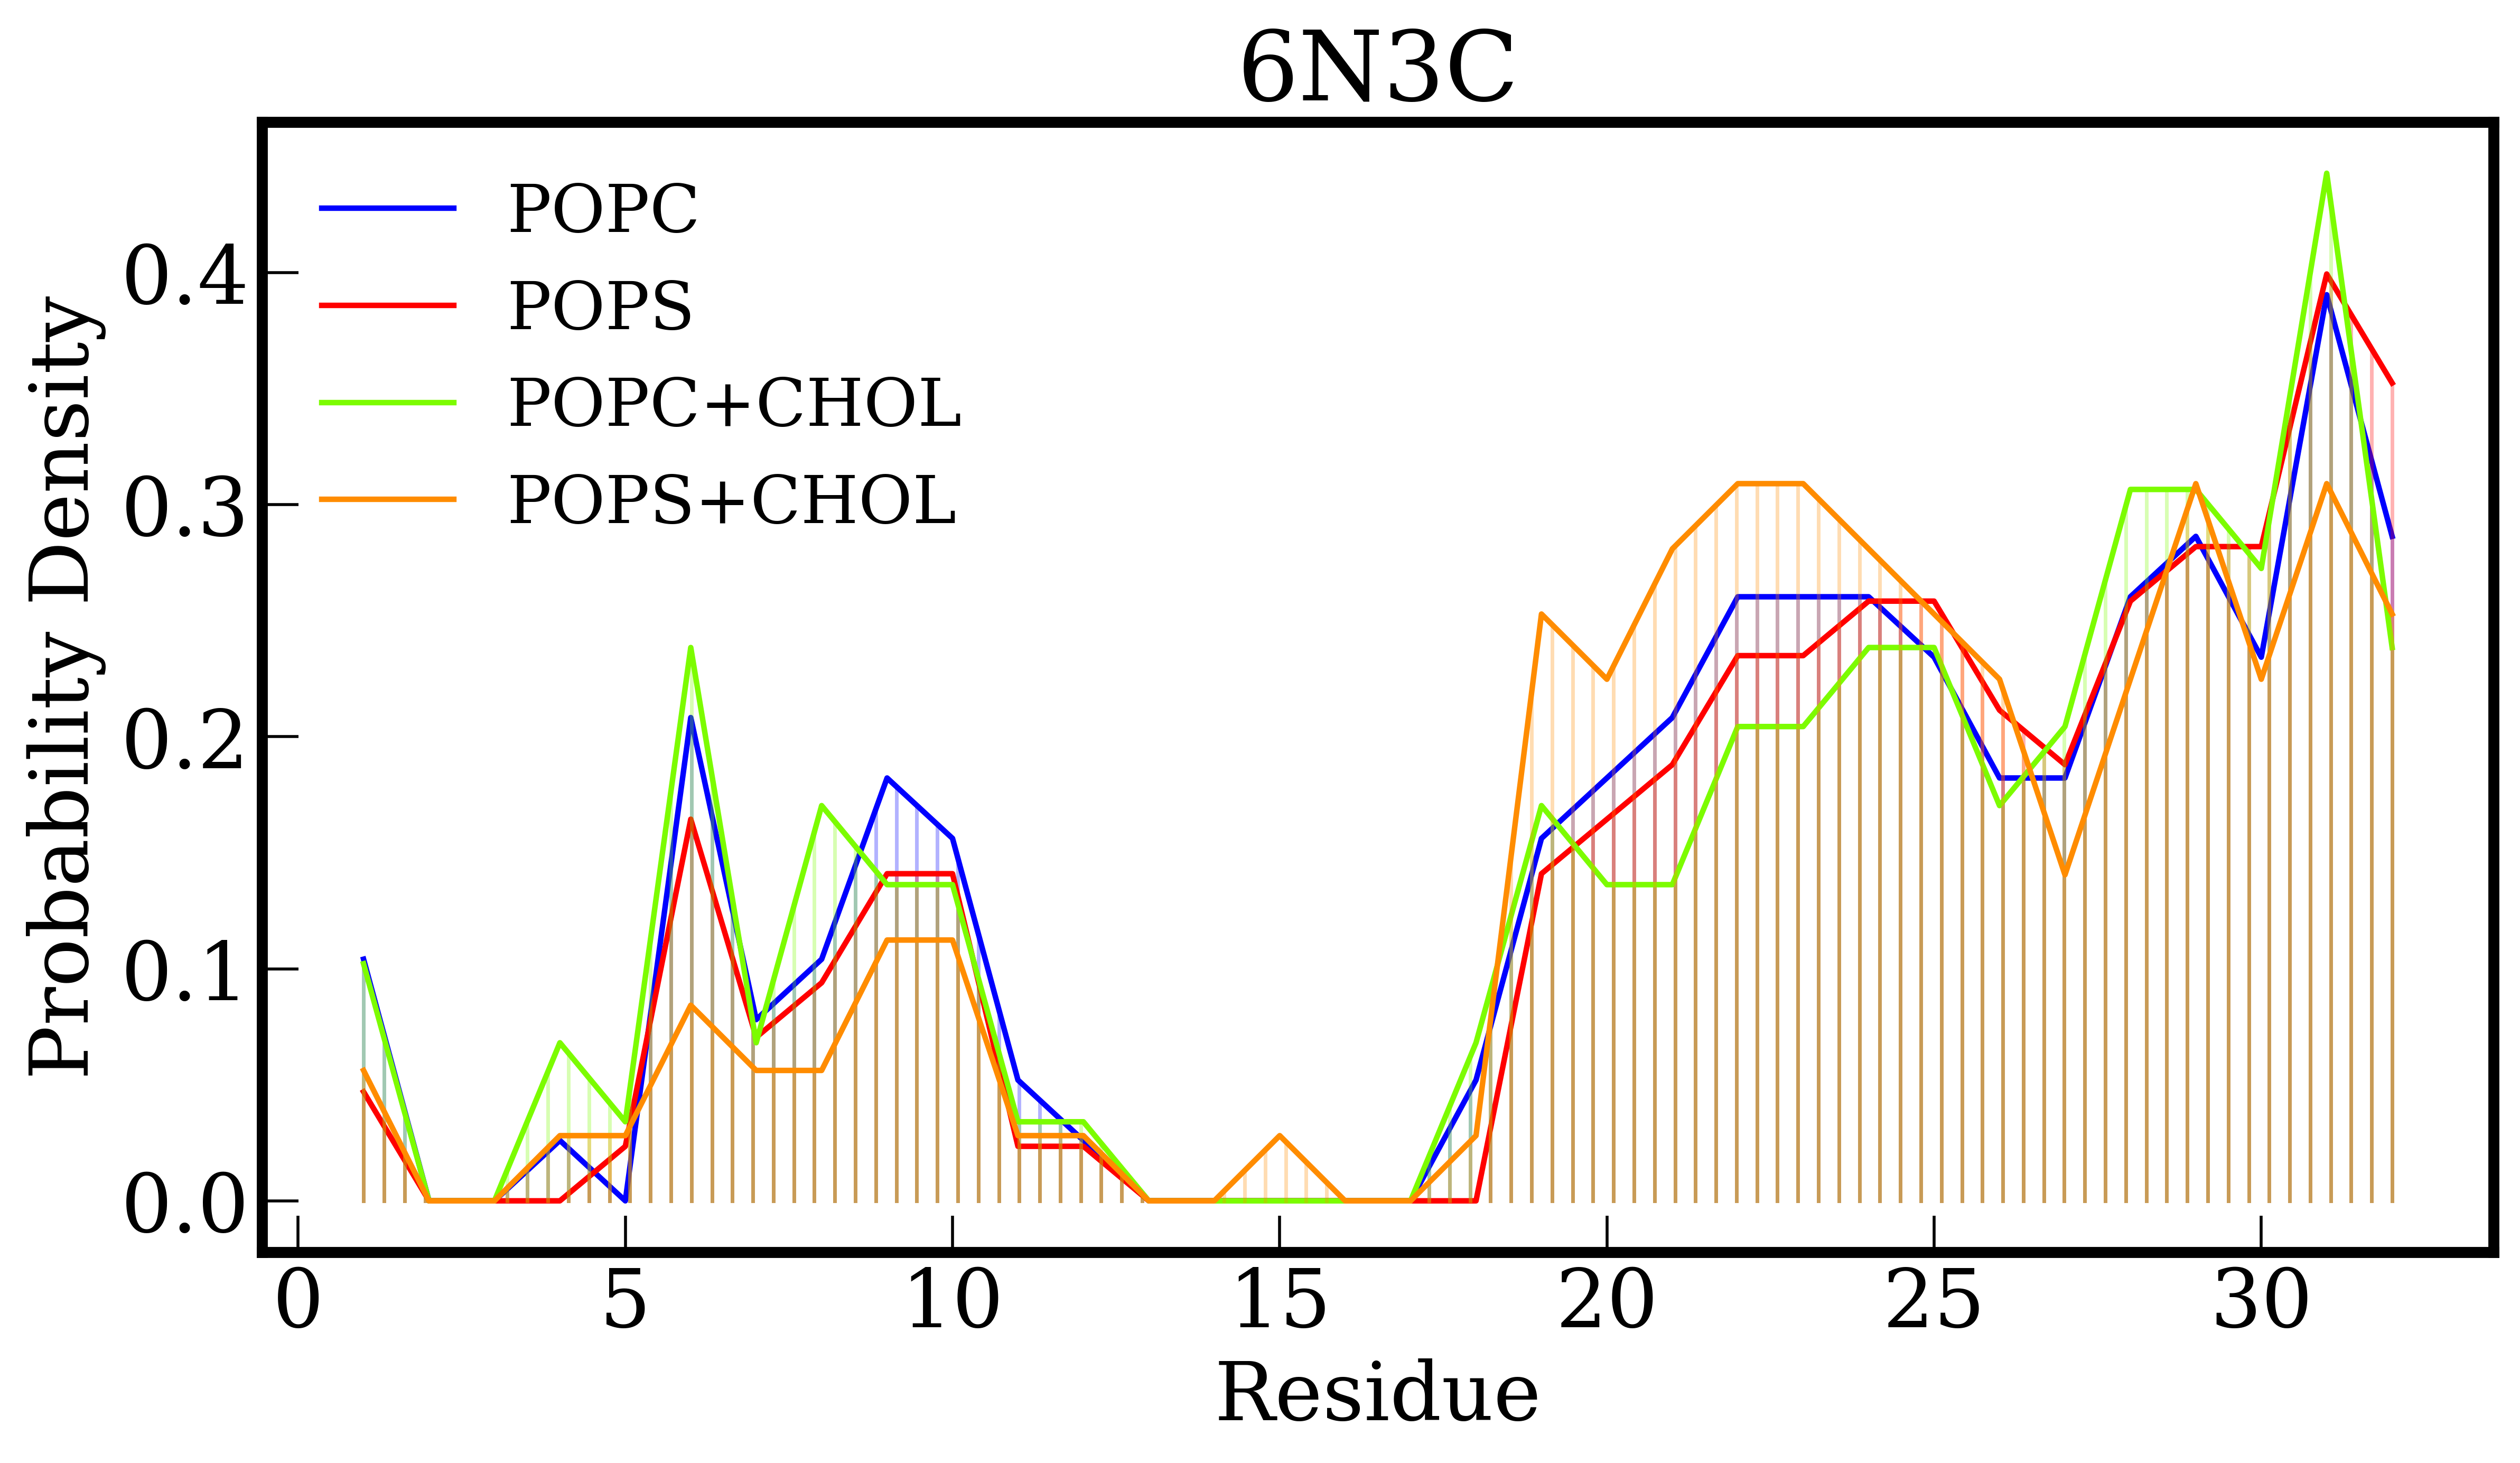

In [15]:
plt.figure(figsize=(10, 6), dpi=500)
plot_normalized_contact_map("POPC/6N3C+POPC.gro", "POPC", 10.0, color="blue",label="POPC")
plot_normalized_contact_map("POPS/6N3C+POPS.gro", "POPS", 10.0, color="red",label="POPS")
plot_normalized_contact_map("POPC+CHOL/6N3C+POPC+CHOL.gro", "POPC", 10.0, color="lawngreen",label="POPC+CHOL")
plot_normalized_contact_map("POPS+CHOL/6N3C+POPS+CHOL.gro","POPS",10.0, color="darkorange",label="POPS+CHOL")

plt.ylabel('Probability Density')
plt.xlabel('Residue')
plt.tick_params(axis='both', which='major')
plt.legend(loc="best")
plt.title("6N3C")
plt.tight_layout()
plt.savefig("6N3C_per_residue_contact.png",dpi=500)
plt.show()